**1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**2. Import Dataset & Basic Check**

We load the dataset, check out the first few rows, and inspect the dataset's shapes and datatypes.

In [9]:
# Load the dataset
df = pd.read_csv('auto-mpg.csv')

# View first 5 rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [10]:
# Check data summary (Equivalent to HouseDF.info())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [11]:
# Check statistical overview (Equivalent to HouseDF.describe())
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


**3. Data Cleaning (Handling Missing Values)**

Note: The Auto MPG dataset sometimes features ? characters in the 'horsepower' column. We need to handle this to ensure the model runs correctly.

In [12]:
# Replace '?' with NaN and convert horsepower to float
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = df['horsepower'].astype(float)

# Drop rows with missing values
df.dropna(inplace=True)

**4. Exploratory Data Analysis (EDA)**

Visualizing correlations is critical to understanding how features impact your target variable (mpg).

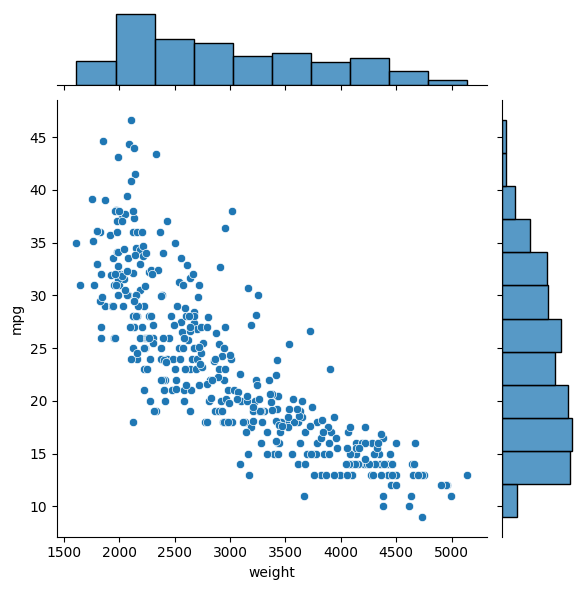

In [13]:
# Jointplot to see relationship between Weight and MPG
sns.jointplot(x='weight', y='mpg', data=df, kind='scatter')
plt.show()

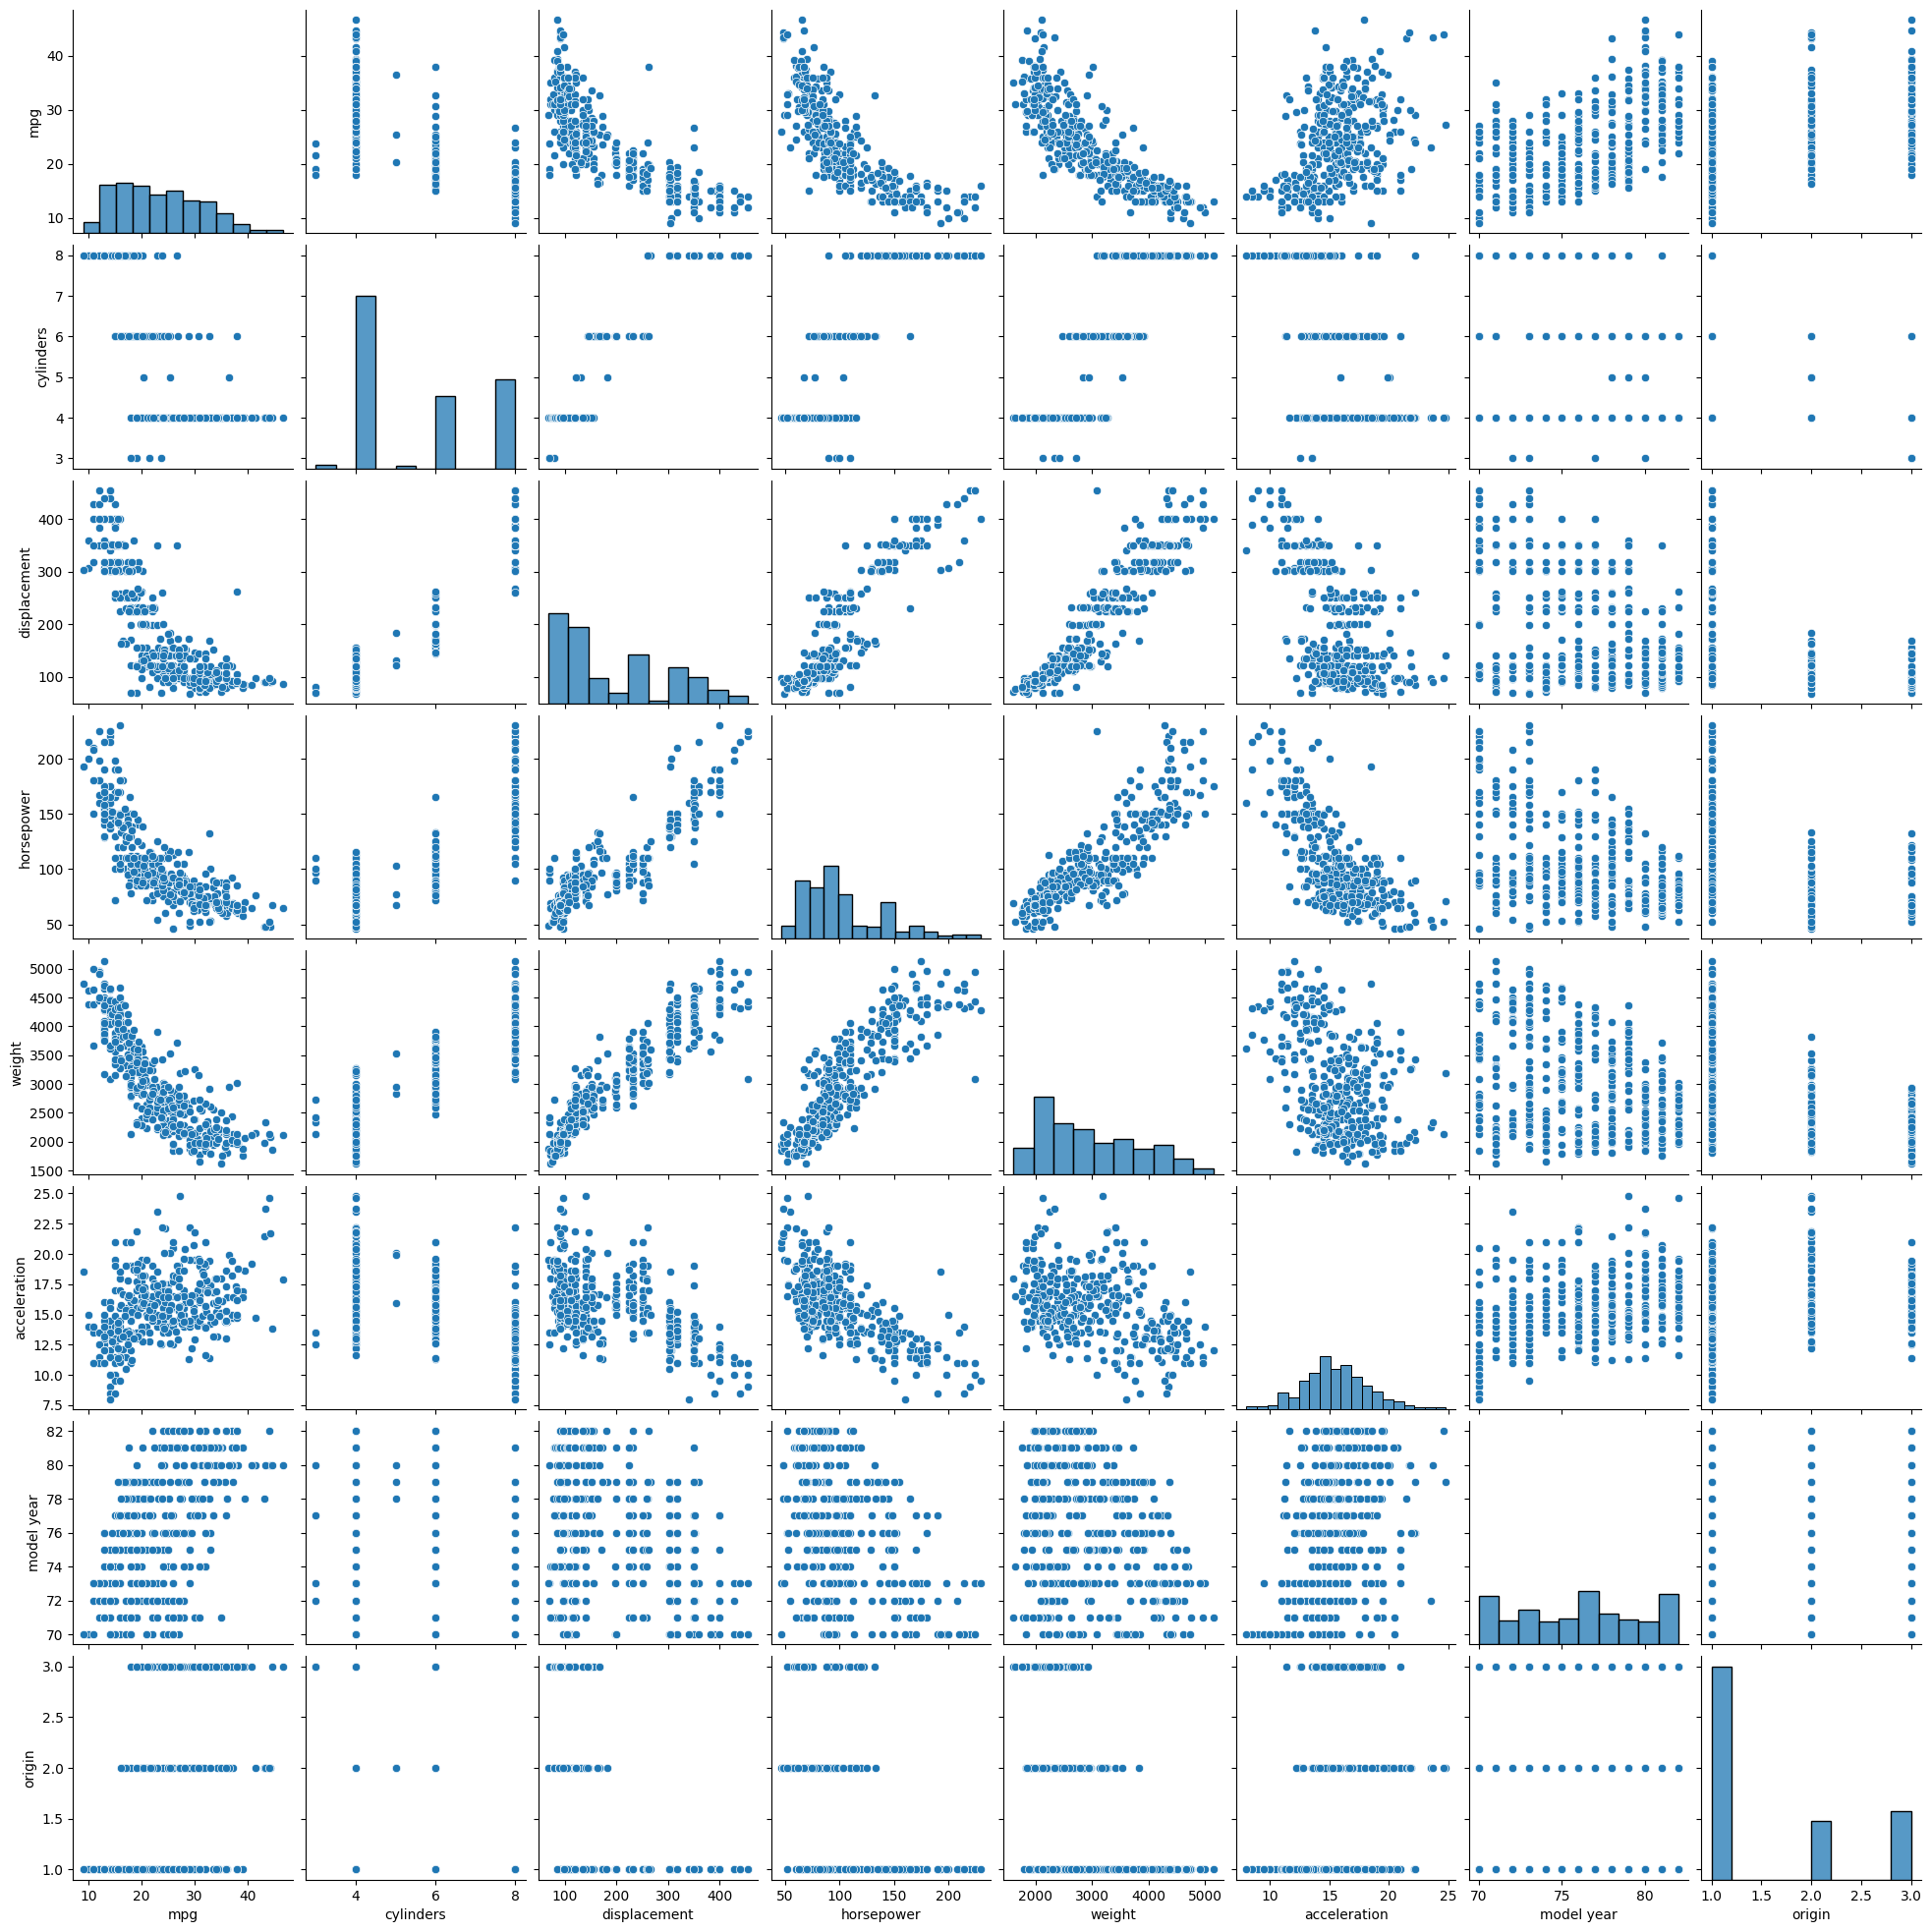

In [14]:
# Pairplot to visualize relations across the entire dataset
# Excluding the 'car name' column as it is textual categorical
sns.pairplot(df.drop('car name', axis=1))
plt.show()

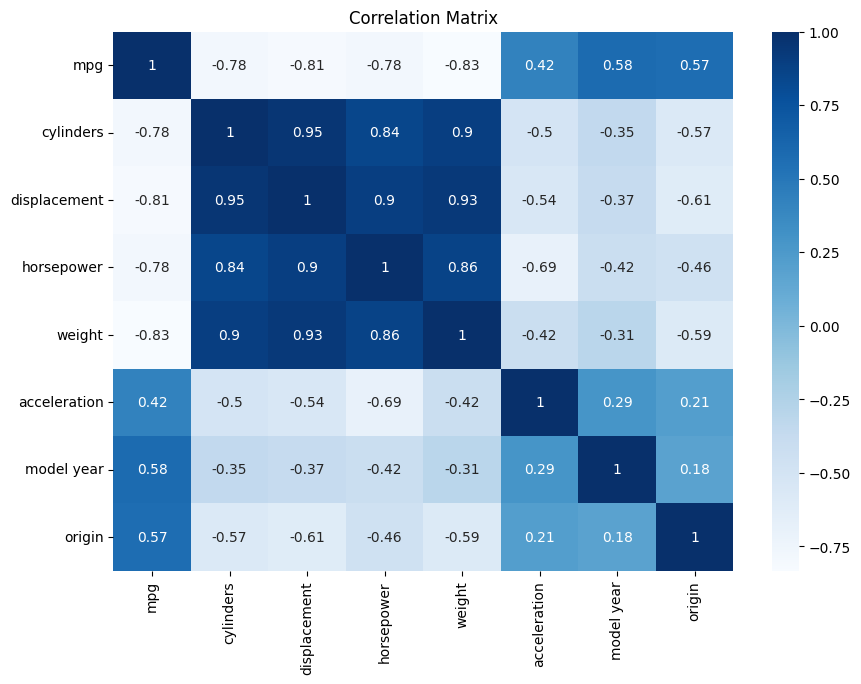

In [15]:
# Heatmap to check feature correlations
plt.figure(figsize=(10, 7))
sns.heatmap(df.drop('car name', axis=1).corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

**5. Training a Linear Regression Model**

Now, we split our data into an X array (features we use to predict) and a y array (the target variable we want to predict).

In [16]:
# Features (Dropping 'mpg' because it's the target, and 'car name' because it's text)
X = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']]

# Target Variable
y = df['mpg']

**Train-Test Split**

In [17]:
from sklearn.model_selection import train_test_split

# Splitting 60% for training and 40% for testing (similar to your example)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

**Creating and Training the Model**

In [18]:
from sklearn.linear_model import LinearRegression

# Instantiate the model
lm = LinearRegression()

# Train (Fit) the model
lm.fit(X_train, y_train)

LinearRegression()

**6. Model Evaluation**

Let's evaluate the model by checking its intercept and coefficients.

In [19]:
# Print the intercept
print("Intercept:", lm.intercept_)

Intercept: -22.12748931465633


In [20]:
# Creating a DataFrame to display coefficients cleanly
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
cylinders,-0.393755
displacement,0.016767
horsepower,0.003355
weight,-0.007101
acceleration,0.173854
model year,0.796421
origin,1.288426


**7. Predictions from our Model**

Now we grab predictions off our test set and see how well it did!

In [21]:
predictions = lm.predict(X_test)

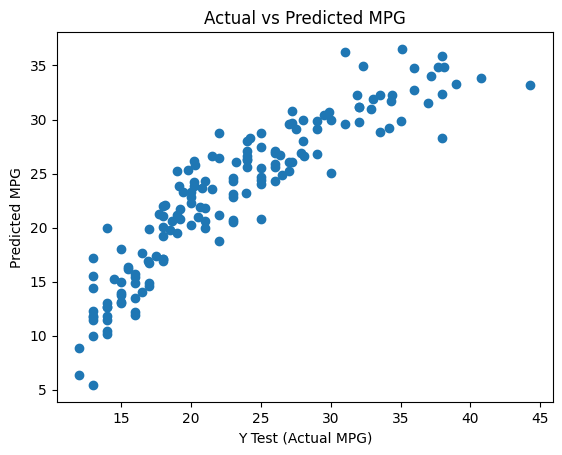

In [22]:
# Scatter plot comparing actual test values vs predicted values
plt.scatter(y_test, predictions)
plt.xlabel('Y Test (Actual MPG)')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.show()

**Residual Histogram**

Checking if the residuals (the differences between actual and predicted values) are normally distributed helps confirm if Linear Regression was an appropriate algorithm choice.

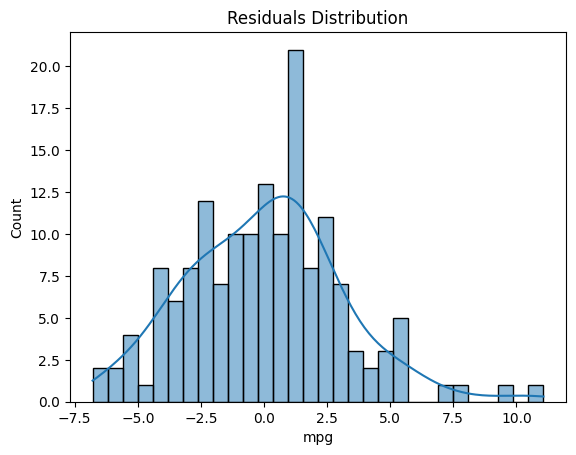

In [23]:
# Histogram of residuals
sns.histplot((y_test - predictions), bins=30, kde=True)
plt.title('Residuals Distribution')
plt.show()

**8. Regression Evaluation Metrics**

We use regression metrics to calculate the error rates of our model:

Mean Absolute Error (MAE)

Mean Squared Error (MSE)

Root Mean Squared Error (RMSE)

In [24]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 2.4178107648074216
MSE: 9.508937470891686
RMSE: 3.083656509874549
